In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("hypertension_dataset.csv")

In [3]:
# Очистка и предварительная обработка данных
df['Medication'] = df['Medication'].fillna('None')
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})

cols_to_drop = [col for col in [
    'Medication_Beta Blocker',
    'Medication_Other',
    'Medication_None',
    'Exercise_Level_Moderate',
    'Exercise_Level_Low',
    'Has_Hypertension'
] if col in df.columns]

X = df.drop(cols_to_drop, axis=1)
y = df['Has_Hypertension']

# Масштабирование числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [4]:
# Инициализация классификаторов
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "KNN (k=10)": KNeighborsClassifier(n_neighbors=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Naive Bayes": GaussianNB()
}

In [5]:
# Параметры для кросс-валидации с изменяемой долей удержания
num_total_samples = len(X_scaled)
n_classes = len(np.unique(y))  # Определяем количество классов

# Устанавливаем минимальное количество объектов для теста в 1.
# Это позволяет провести "удержание с одним объектом".
min_test_samples = 1
max_test_samples = int(num_total_samples * 0.5)

# Создаем список количества объектов для теста
num_points_for_plot = 15  # Количество точек на графике
test_sample_counts = np.linspace(min_test_samples, max_test_samples, num_points_for_plot, dtype=int)
test_sample_counts = np.unique(test_sample_counts)  # Убираем дубликаты
test_sample_counts = test_sample_counts[test_sample_counts > 0]  # Убираем 0, если вдруг появился

# Количество повторений для каждой доли удержания
n_splits_per_fraction = 20

In [6]:
# Словарь для хранения результатов:
all_metrics_results = {
    name: {
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1': [],
        'ROC AUC': []
    } for name in classifiers.keys()
}
# Список для хранения фактических долей удержания для построения графиков
actual_holdout_fractions = []

print(f"Начинаем кросс-валидацию с изменяемым количеством объектов для контроля. Всего {num_total_samples} объектов.")
print(f"Количество объектов для тестирования: {test_sample_counts}")

Начинаем кросс-валидацию с изменяемым количеством объектов для контроля. Всего 1985 объектов.
Количество объектов для тестирования: [  1  71 142 213 284 354 425 496 567 638 708 779 850 921 992]


In [7]:
# Проведение кросс-валидации
for test_size_samples in test_sample_counts:
    holdout_fraction = test_size_samples / num_total_samples
    actual_holdout_fractions.append(holdout_fraction)

    # Временные списки для усреднения метрик по повторениям
    temp_metrics = {name: {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC AUC': []}
                    for name in classifiers.keys()}

    for _ in range(n_splits_per_fraction):
        if test_size_samples == 1:
            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=test_size_samples, random_state=None
            )
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=test_size_samples, random_state=None, stratify=y
            )

        for name, model in classifiers.items():
            try:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                y_proba = None
                if hasattr(model, "predict_proba"):
                    y_proba = model.predict_proba(X_test)[:, 1]
                elif hasattr(model, "decision_function"):
                    y_proba = model.decision_function(X_test)

                temp_metrics[name]['Accuracy'].append(accuracy_score(y_test, y_pred))
                temp_metrics[name]['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
                temp_metrics[name]['Recall'].append(recall_score(y_test, y_pred, zero_division=0))
                temp_metrics[name]['F1'].append(f1_score(y_test, y_pred, zero_division=0))

                # Проверяем, что в y_test есть хотя бы два класса для ROC AUC и что y_proba доступен.
                if len(np.unique(y_test)) > 1 and y_proba is not None:
                    temp_metrics[name]['ROC AUC'].append(roc_auc_score(y_test, y_proba))
                else:
                    temp_metrics[name]['ROC AUC'].append(np.nan)
            except Exception as e:
                for metric_name in temp_metrics[name].keys():
                    temp_metrics[name][metric_name].append(np.nan)


    # Усредняем результаты и добавляем в основной словарь
    for name in classifiers.keys():
        for metric_name in all_metrics_results[name].keys():
            all_metrics_results[name][metric_name].append(np.nanmean(temp_metrics[name][metric_name]))

print("\nКросс-валидация завершена. Строим графики...")


Кросс-валидация завершена. Строим графики...


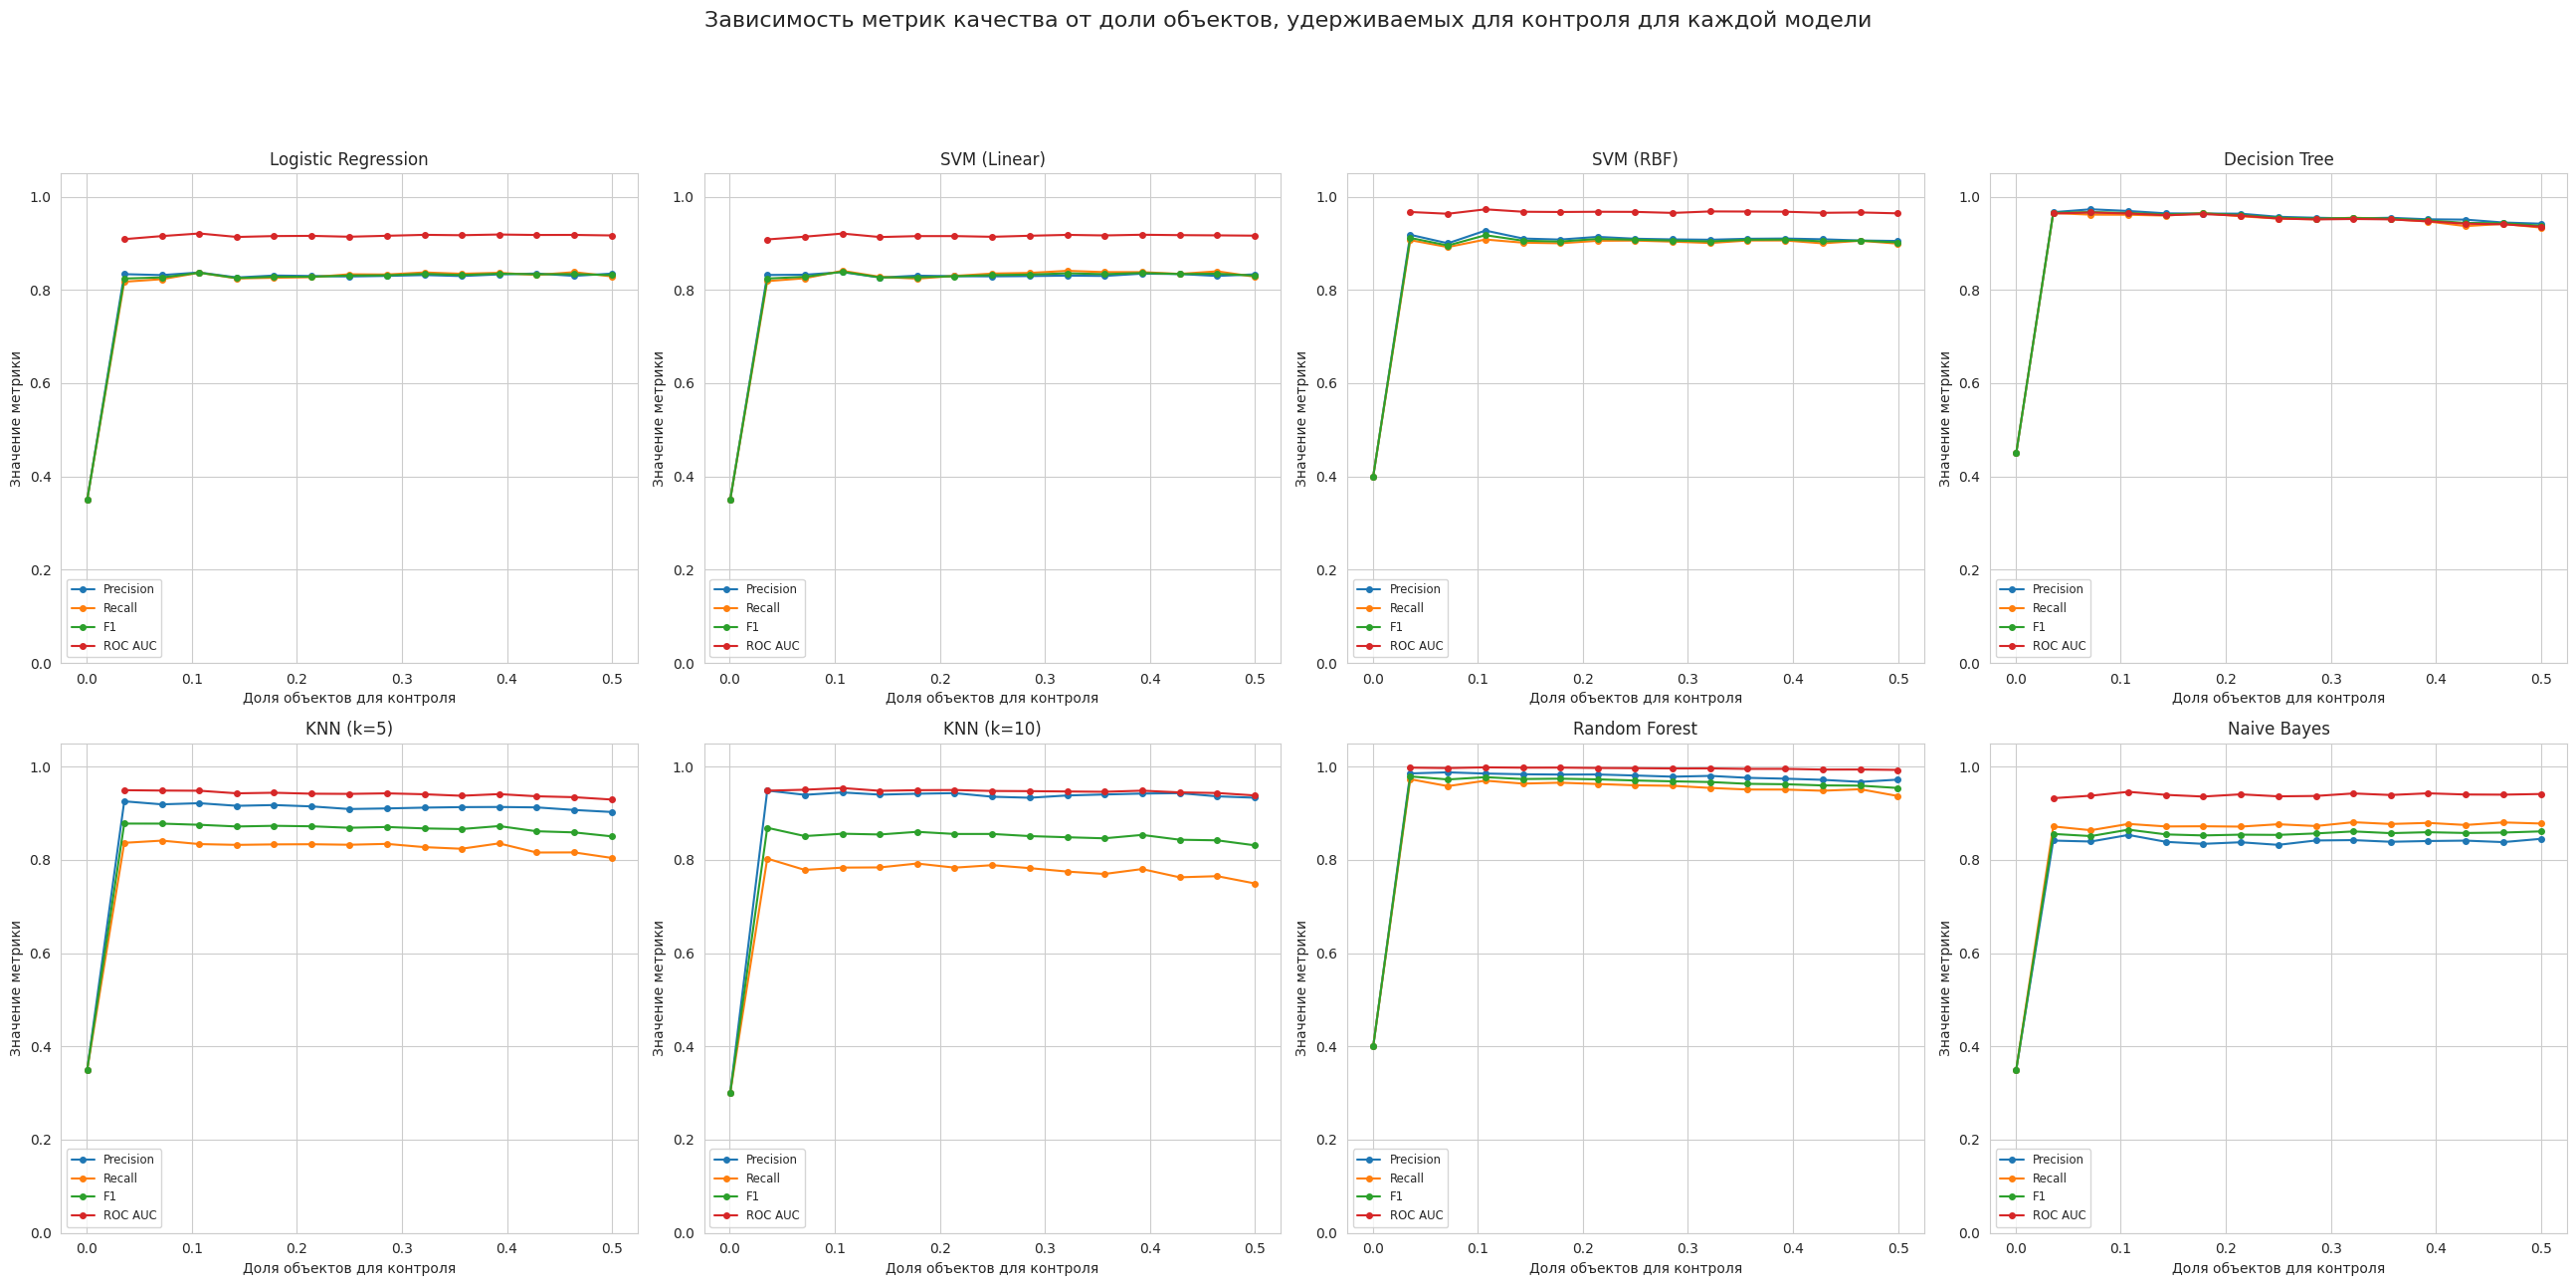


Анализ завершен. График со всеми моделями построен и сохранен как 'all_models_metrics.png'.


In [11]:

# Построение графиков для каждой модели на одной картинке
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})

num_models = len(classifiers)

n_rows = 2
n_cols = 4

subplot_side_inches = 6.5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * subplot_side_inches, n_rows * subplot_side_inches), sharex=False, sharey=False)
axes = axes.flatten()
fig.suptitle('Зависимость метрик качества от доли объектов, удерживаемых для контроля для каждой модели', y=1.02, fontsize=16)

metrics_to_plot_labels = [ 'Precision', 'Recall', 'F1', 'ROC AUC']

for i, (classifier_name, metrics_data) in enumerate(all_metrics_results.items()):
    ax = axes[i]

    for metric_name in metrics_to_plot_labels:
        values = metrics_data[metric_name]
        valid_indices = [idx for idx, val in enumerate(values) if not np.isnan(val)]
        if valid_indices:
            ax.plot(np.array(actual_holdout_fractions)[valid_indices], np.array(values)[valid_indices],
                    marker='o', linestyle='-', markersize=4, label=metric_name)

    ax.set_title(classifier_name, fontsize=12)
    ax.set_ylim(0.0, 1.05)
    ax.grid(True)

    # Подписываем оси для каждого графика
    ax.set_ylabel('Значение метрики', fontsize=10)
    ax.set_xlabel('Доля объектов для контроля', fontsize=10)

    # Легенда для каждого графика
    ax.legend(loc='lower left', bbox_to_anchor=(0.0, 0.0), fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('all_models_metrics.png', dpi=300)
plt.show()

print("\nАнализ завершен. График со всеми моделями построен и сохранен как 'all_models_metrics.png'.")



## **Анализ графиков:**

Определение уточненного значения доли объектов, обеспечивающих максимальное значение для каждой метрики качества:

Для всех моделей и всех метрик наблюдается резкий рост значений метрик при переходе от 0.0 к 0.05 доле объектов для контроля. Это указывает на то, что для адекватной оценки модели требуется хотя бы минимальное количество данных для тестирования.
Практически для всех моделей и всех метрик максимальные значения достигаются при доле объектов для контроля, равной 0.05 (5%), либо метрики выходят на плато при этом значении и остаются относительно стабильными в дальнейшем диапазоне (до 0.5).


1. Logistic Regression: Precision, Recall, F1: Максимум достигается при 0.05 или 0.1, далее стабильно (около 0.83).
 ROC AUC: Максимум при 0.05 или 0.1, далее стабильно (около 0.91).

2. SVM (Linear): Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее стабильно.

3. SVM (RBF): Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее стабильно.

4. Decision Tree: Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее постепенно снижается.

5. KNN (k=5): Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее постепенно снижается (особенно Recall и F1).

6. KNN (k=10): Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее относительно стабильно, с небольшим снижением Recall.

7. Random Forest: Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее очень стабильно и на очень высоком уровне.

8. Naive Bayes: Precision, Recall, F1, ROC AUC: Максимум достигается при 0.05, далее относительно стабильно с небольшим колебанием.

## **Вывод:**


Для большинства моделей и метрик качества, представленных на графиках, оптимальное значение доли объектов, удерживаемых для контроля, составляет 0.05 (5%). При этом значении достигаются максимальные значения метрик, либо наблюдается выход на плато, после которого дальнейшее увеличение тестовой выборки не приводит к существенному улучшению (а иногда и к небольшому снижению) производительности.


Резкий рост метрик от 0.0 к 0.05 четко показывает, что для надежной оценки качества модели необходимо иметь хотя бы минимальную тестовую выборку.

Для многих моделей (Logistic Regression, SVM, Random Forest, Naive Bayes) значения метрик остаются достаточно стабильными в диапазоне от 0.05 до 0.5 доли объектов для контроля, что говорит о робастности этих моделей к изменению размера тестовой выборки в этом диапазоне.


Модели Decision Tree и KNN показывают более выраженное снижение метрик качества после достижения пика при 0.05, что может указывать на их большую чувствительность к уменьшению объема тренировочных данных при увеличении тестовой выборки.


Метрика ROC AUC часто демонстрирует наибольшую стабильность по сравнению с Precision, Recall и F1 в более широком диапазоне долей объектов для контроля после начального скачка.


Результаты показывают, что использование большой доли данных для контроля (например, 30-50%) нецелесообразно, так как это уменьшает объем тренировочной выборки, часто не приводя к улучшению оценки качества, а иногда и к её незначительному снижению. Доля в 5-10% для контроля оказывается достаточной для получения стабильной и максимальной оценки качества моделей.